In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv('../Dataset/city_day.csv')

### Data Cleaning ###

In [63]:
df.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene
27,73.24,95.595,5.72,21.11,25.84,16.53,5.72,36.52,62.42,0.03,0.01
28,83.13,95.595,6.93,28.71,33.72,16.53,6.93,49.52,59.76,0.02,0.00
29,79.84,95.595,13.85,28.68,41.08,16.53,13.85,48.49,97.07,0.04,0.00
30,94.52,95.595,24.39,32.66,52.61,16.53,24.39,67.39,111.33,0.24,0.01
31,135.99,95.595,43.48,42.08,84.57,16.53,43.48,75.23,102.70,0.40,0.04


In [64]:
df.isnull().sum()

PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64

In [59]:
df.shape

(29531, 16)

In [60]:
df = df.dropna(subset=['PM2.5'])
# pm2.5 is our prediction traget, so we will drop the rows where pm2.5 is null

In [19]:
df.dtypes

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
AQI           float64
AQI_Bucket     object
dtype: object

In [22]:
df['AQI'].unique()

array([  nan,  209.,  328.,  514.,  782.,  914.,  660.,  294.,  149.,
        190.,  247.,  379.,  341.,  256.,  388.,  288.,  510.,  761.,
        475.,  536.,  479.,  592.,  427.,  588., 1141.,  669., 1247.,
        411.,  292.,  189.,  408.,  383.,  780.,  233.,  297.,  330.,
        252.,  244.,  234.,  219.,  118.,  231.,  286.,  883.,  720.,
        570.,  589.,  818.,  737.,  585.,  616.,  437.,  321.,  372.,
        339.,  324.,  222.,  169.,  220.,  303.,  314.,  378.,  415.,
        126.,  175.,  226.,  315.,  678.,  774.,  285.,  358.,  357.,
        214.,  253.,  239.,  300.,  317.,  240.,  344.,  503.,  308.,
        227.,  120.,  158.,  177.,  201.,  211.,  221.,  481.,  352.,
        327.,  577.,  212.,  280.,  162.,  569.,  128.,  129.,  152.,
        176.,  167.,  106.,  174.,  185.,  179.,  192.,  310.,  223.,
        191.,  184.,  215.,  251.,  216.,  237.,  198.,  195.,  187.,
        181.,  188.,  196.,  230.,  243.,  199.,  200.,  241.,  248.,
        232.,  105.,

In [61]:
cols_fill = [
    "PM10","NO","NO2","NOx","NH3",
    "CO","SO2","O3","Benzene","Toluene"
]

for col in cols_fill:
    df[col] = df[col].fillna(df[col].median())

In [62]:
# Remove Xylene (81% missing values)
df = df.drop(columns=['Xylene'])
df = df.drop(columns=['Date'],axis=1)
df = df.drop(columns=['City'],axis=1)
df = df.drop(['AQI','AQI_Bucket'],axis=1)

### EDA (Exploratory Data Analysis)  ### 

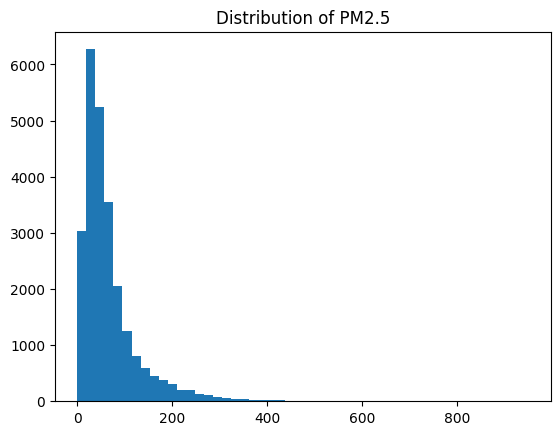

In [65]:
plt.hist(df['PM2.5'], bins=50)
plt.title('Distribution of PM2.5')
plt.show() 

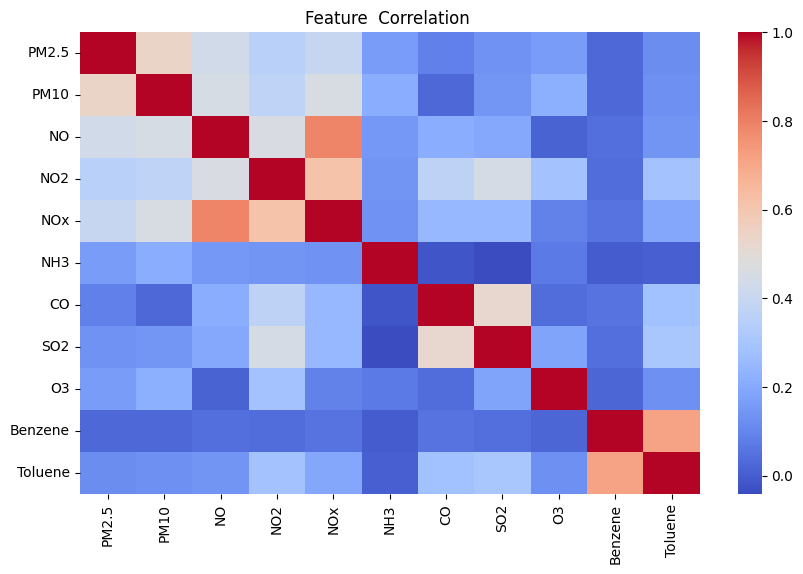

In [66]:
# correlation heatmap 

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=False,cmap='coolwarm')
plt.title("Feature  Correlation ")
plt.show()

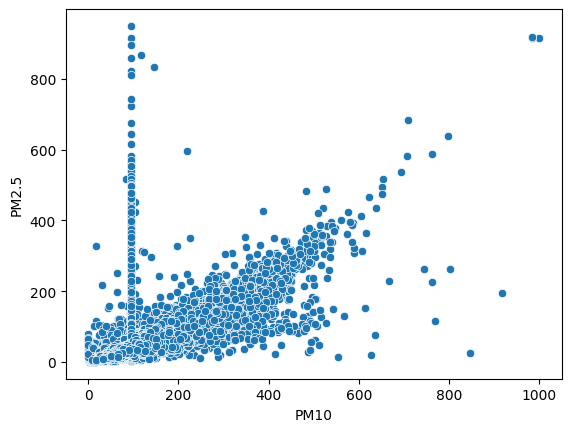

In [32]:
sns.scatterplot(x='PM10',y='PM2.5',data=df)
plt.show() 

### Feature & Target ### 

In [67]:
X = df.drop("PM2.5",axis=1)
y = df['PM2.5']

In [68]:
from sklearn.model_selection import train_test_split 

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

### Model Training ### 

In [69]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

### Evaluation ### 

In [70]:
from sklearn.metrics import mean_absolute_error,r2_score 

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 17.019513174253056
R2 Score: 0.700372977673167


### Boosting ### 

In [39]:
pip install xgboost


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [71]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

params = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

model = XGBRegressor(random_state=42)

grid = GridSearchCV(
    model,
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}


In [72]:
best_model = grid.best_estimator_

In [73]:
y_pred = best_model.predict(X_test)
print("Final MAE:", mean_absolute_error(y_test, y_pred))
print("Final R2 Score:", r2_score(y_test, y_pred))

Final MAE: 16.782529439465996
Final R2 Score: 0.7175166038575711


### using Decision Tree Regressor ### 

In [ ]:
# from sklearn.tree import DecisionTreeRegressor 
# model = DecisionTreeRegressor(
#     max_depth=5,          # controls overfitting
#     random_state=42
# )

# model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
# y_pred = model.predict(X_test)

# from sklearn.metrics import mean_absolute_error, r2_score

# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("R2 Score:", r2_score(y_test, y_pred))

MAE: 24.945996230877903
R2 Score: 0.5217708139878496


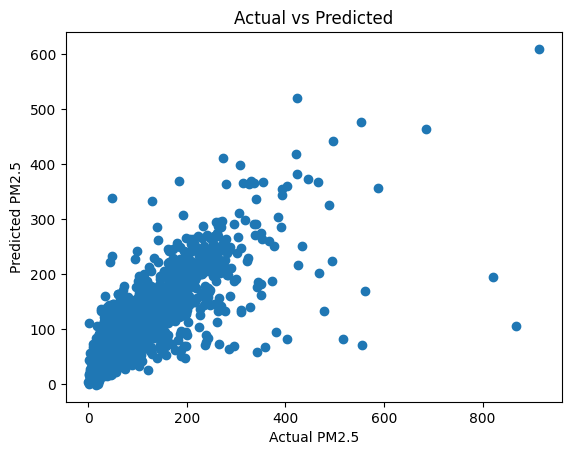

In [74]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted")
plt.show()

### save model ###

In [75]:
import pickle 
with open("api_predictor.pkl","wb") as f:
    pickle.dump(best_model,f)